Accuracy: 0.8912
              precision    recall  f1-score   support

           0       0.90      0.77      0.83      3422
           1       0.89      0.96      0.92      6578

    accuracy                           0.89     10000
   macro avg       0.89      0.86      0.87     10000
weighted avg       0.89      0.89      0.89     10000

Saved tree image.


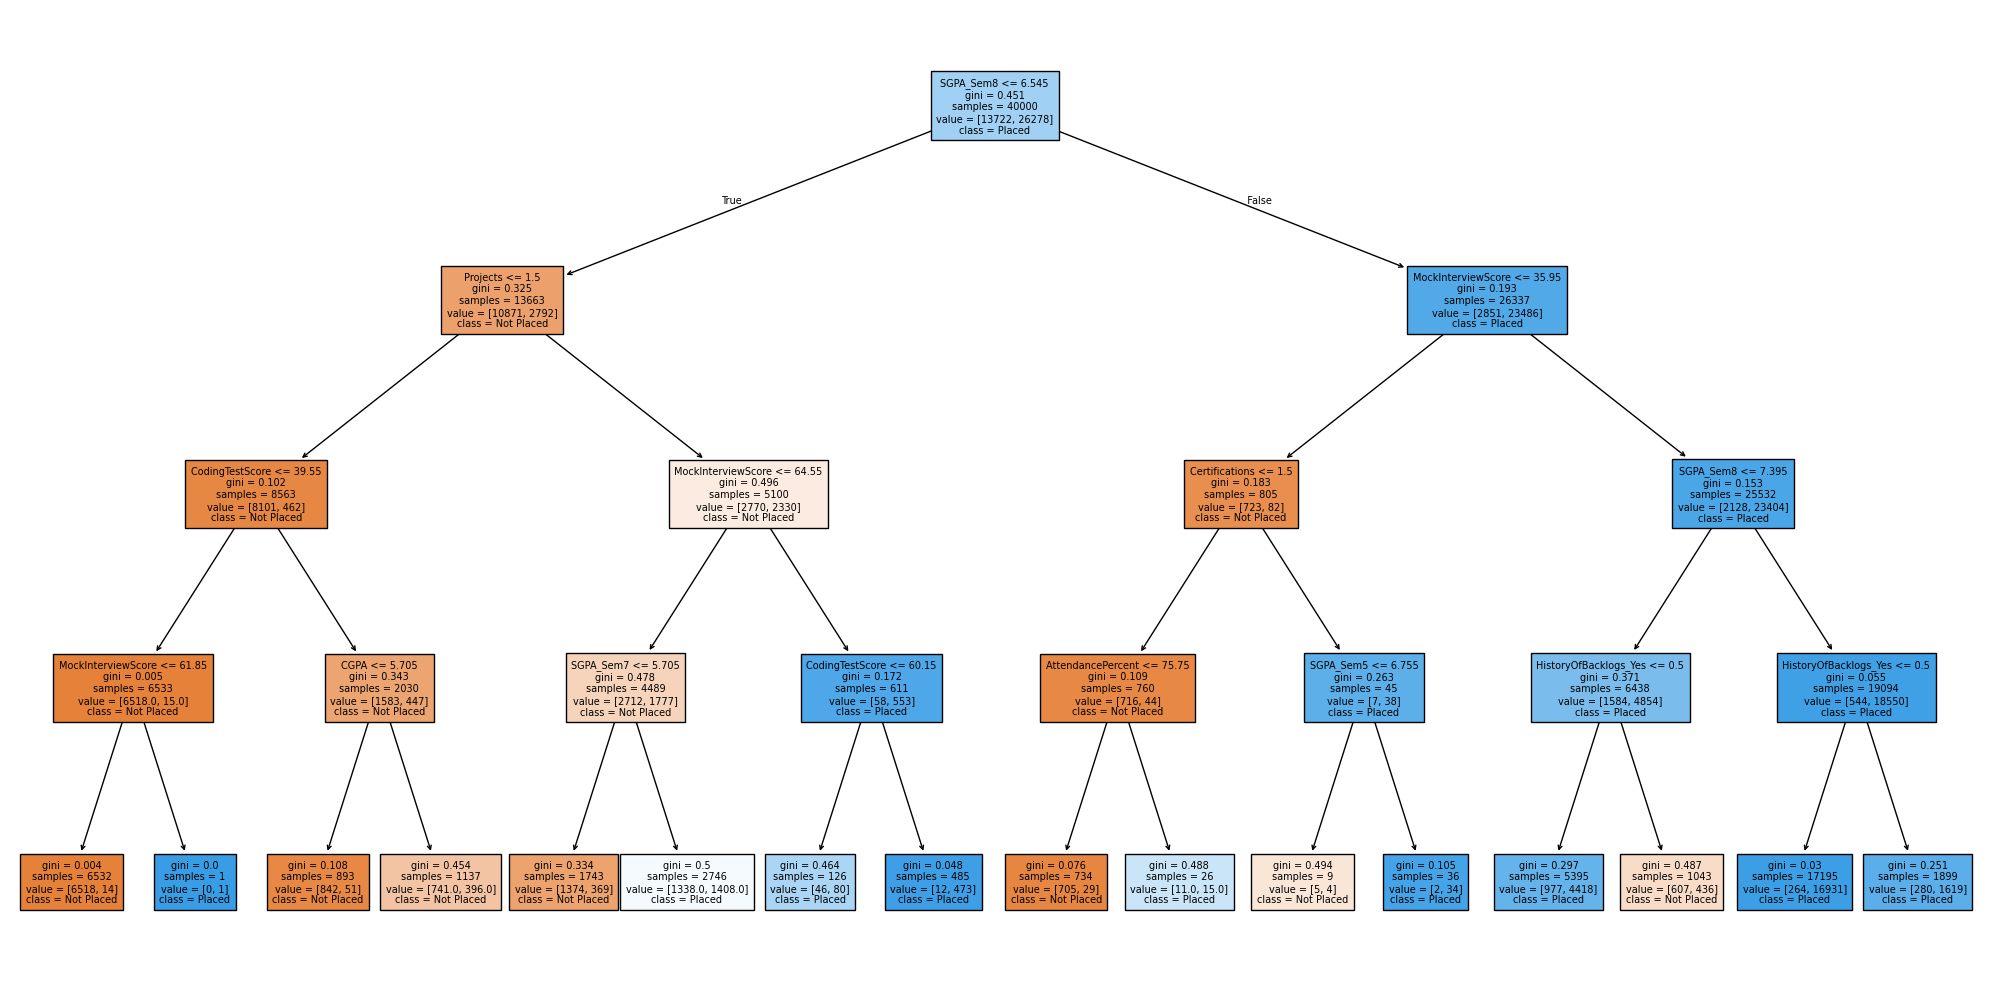

In [5]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, classification_report
import matplotlib.pyplot as plt

df = pd.read_csv('placement_predict_50k Dataset.csv')
df = df.drop(columns=['IsAnomaly'])

# Drop StudentID early as it's an identifier and not a predictor
if 'StudentID' in df.columns:
    df = df.drop(columns=['StudentID'])

for col in df.columns:
    if pd.api.types.is_numeric_dtype(df[col]):
        df[col] = df[col].fillna(df[col].median())
    else:
        # Fill NaNs for object columns using mode. This is before Salary Package specific mapping.
        df[col] = df[col].fillna(df[col].mode()[0])

# Map 'Salary Package' from categorical strings to numerical values
if 'Salary Package' in df.columns:
    # Ensure all values are strings and strip whitespace to catch variations like ' High'
    df['Salary Package'] = df['Salary Package'].astype(str).str.strip()
    salary_mapping = {'Low': 0, 'Medium': 1, 'High': 2}
    # Apply mapping; values not in salary_mapping will become NaN
    df['Salary Package'] = df['Salary Package'].map(salary_mapping)
    # Convert the column to a numeric type, coercing any remaining non-numeric (e.g., from unmapped strings) to NaN
    df['Salary Package'] = pd.to_numeric(df['Salary Package'], errors='coerce')
    # Fill any NaNs (from original data, unmapped values, or coerced non-numerics)
    # Check if all values are NaN before calling median to prevent error on empty numeric series
    if df['Salary Package'].isnull().all():
        df['Salary Package'] = df['Salary Package'].fillna(0) # Default to 0 if all are NaN
    else:
        df['Salary Package'] = df['Salary Package'].fillna(df['Salary Package'].median())

# Identify columns for one-hot encoding
categorical_cols_for_dummies = [
    'Gender', 'City', 'CollegeTier', 'Stream', 'Specialisation',
    'Hostel', 'HistoryOfBacklogs', 'ExtraCurricular'
]

# Filter out columns that might have been dropped or don't exist in the current df
categorical_cols_for_dummies = [col for col in categorical_cols_for_dummies if col in df.columns]

df_encoded = pd.get_dummies(df, columns=categorical_cols_for_dummies, drop_first=True)

X = df_encoded.drop(columns=['PlacementStatus'])
y = df_encoded['PlacementStatus']

# It is good practice to ensure all columns in X are numeric
# This step is crucial if other unexpected object columns could exist or if get_dummies failed something.
# Convert any remaining non-numeric columns in X to numeric, coercing errors
for col in X.select_dtypes(include=['object', 'category']).columns:
    X[col] = pd.to_numeric(X[col], errors='coerce')
    if X[col].isnull().any():
        # Fill NaNs that resulted from coercion, e.g., with 0 or mean/median
        # Using 0 as a robust default, but median could be better if distribution allows
        X[col] = X[col].fillna(0)


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = DecisionTreeClassifier(max_depth=4, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

plt.figure(figsize=(20, 10))
plot_tree(model, feature_names=X.columns, class_names=['Not Placed', 'Placed'], filled=True, fontsize=7)
plt.tight_layout()
plt.savefig('decision_tree.png', dpi=150)
print("Saved tree image.")

In [10]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

RANDOM_STATE = 42

# ---------------------------------------------------------------------
# 1. Load the simple dataset
# ---------------------------------------------------------------------
df = pd.read_csv("placement_predict_50k Dataset.csv")

# Drop StudentID early as it's an identifier and not a predictor
if 'StudentID' in df.columns:
    df = df.drop(columns=['StudentID'])

# Drop IsAnomaly as it was dropped in the other notebook as well
if 'IsAnomaly' in df.columns:
    df = df.drop(columns=['IsAnomaly'])

print("Sample of the dataset:")
print(df.head())
print(f"\nDataset shape: {df.shape}")

TARGET = "PlacementStatus"
DROP_COLS = []  # StudentID and IsAnomaly are already dropped if present

print(f"Class balance:\n{df[TARGET].value_counts()}")

# Fill NaNs for numeric columns using median
for col in df.select_dtypes(include=['number']).columns:
    df[col] = df[col].fillna(df[col].median())

# Map 'Salary Package' from categorical strings to numerical values
if 'Salary Package' in df.columns:
    df['Salary Package'] = df['Salary Package'].astype(str).str.strip()
    salary_mapping = {'Low': 0, 'Medium': 1, 'High': 2}
    df['Salary Package'] = df['Salary Package'].map(salary_mapping)
    df['Salary Package'] = pd.to_numeric(df['Salary Package'], errors='coerce')
    if df['Salary Package'].isnull().all():
        df['Salary Package'] = df['Salary Package'].fillna(0)
    else:
        df['Salary Package'] = df['Salary Package'].fillna(df['Salary Package'].median())

# Identify categorical columns for one-hot encoding (excluding 'Salary Package' which is now numeric)
categorical_cols = [col for col in df.columns if df[col].dtype == 'object' and col != TARGET]

# Fill NaNs for remaining object columns using mode before one-hot encoding
for col in categorical_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

feature_names = [c for c in df_encoded.columns if c not in [TARGET] + DROP_COLS]
X = df_encoded[feature_names].values
y = df_encoded[TARGET].values

# ---------------------------------------------------------------------
# 2. Train / test split
# ---------------------------------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)

# ---------------------------------------------------------------------
# 3. Train a Random Forest
# ---------------------------------------------------------------------
rf = RandomForestClassifier(
    n_estimators=100,
    max_features="sqrt",
    oob_score=True,
    random_state=RANDOM_STATE,
)
rf.fit(X_train, y_train)

# ---------------------------------------------------------------------
# 4. Evaluate
# ---------------------------------------------------------------------
y_pred = rf.predict(X_test)
test_accuracy = accuracy_score(y_test, y_pred)

print(f"\nOOB score: {rf.oob_score_:.4f}")
print(f"Test accuracy: {test_accuracy:.4f}")
print("\nClassification report:")
print(classification_report(y_test, y_pred))

# ---------------------------------------------------------------------
# 5. Feature importances
# ---------------------------------------------------------------------
print("Feature importances:")
# The feature_names list needs to be updated after one-hot encoding.
# Retrieve feature names from df_encoded X.
feature_names_after_encoding = df_encoded[feature_names].columns
for name, importance in sorted(
    zip(feature_names_after_encoding, rf.feature_importances_), key=lambda x: -x[1]
):
    print(f"  {name}: {importance:.4f}")

Sample of the dataset:
   Gender       City CollegeTier Stream Specialisation Hostel  \
0    Male  Ahmedabad       Tier2    ECE     Networking     No   
1  Female     Mumbai       Tier2    ECE    DataScience    Yes   
2    Male    Kolkata       Tier2     IT    DataScience    Yes   
3    Male     Jaipur       Tier1     CS             AI     No   
4    Male       Pune       Tier2     IT    DataScience    Yes   

  HistoryOfBacklogs  SGPA_Sem1  SGPA_Sem2  SGPA_Sem3  ...  Certifications  \
0                No       6.02       6.54       6.52  ...               2   
1               Yes       5.84       5.12       5.34  ...               1   
2                No       4.91       5.29       5.49  ...               1   
3                No       7.67       8.03       8.08  ...               2   
4                No       8.14       8.97       8.36  ...               4   

   Publications  AptitudeTestScore  SoftSkillsRating  CodingTestScore  \
0             0               66.7               2

In [11]:
rf = RandomForestClassifier(
    n_estimators=100,
max_features="sqrt",
oob_score=True,
random_state=RANDOM_STATE,
)


In [12]:
n_estimators=100


In [13]:
max_features="sqrt"


In [14]:
oob_score=True


In [15]:
random_state=RANDOM_STATE
